# Assignment 11.1 - Transformer

Please submit your solution of this notebook in the Whiteboard at the corresponding Assignment entry as .ipynb-file and as .pdf.

#### Please state both names of your group members here:
Rashid Harvey and S M Shameem Ahmed Khan

## Task 11.1.1: Self-Attention

Implement the attention mechanism by yourself. You are free to use torch and numpy to speed up the matrix multiplications, but please don't just use their transformer implementation.

In the image below, you see the design of one Encoder Block. We want you to set up this Block. Please use your implementation of the Self-Attention (doesn't have to be multi-head) and build the Add & Norm and Feed Forward layers on top of it. Add & Norm and the Feed Forward should be implementations by PyTorch or else. You only need to use your own Self-Attention function.

* Show that your model block works, by forwarding a randomly initialized tensor through it once. Print the values of the Random input tensor, the output tensor and the Q,K and V matrices. **(RESULT)** 

In [8]:
from IPython.display import Image
Image(url="https://www.researchgate.net/publication/334288604/figure/fig1/AS:778232232148992@1562556431066/The-Transformer-encoder-structure.ppm", height=300)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [5]:
# Implement Self-Attention from scratch
class SelfAttention(nn.Module):
    """
    Single-head self-attention mechanism.
    Input shape: (batch_size, seq_len, d_model)
    Output shape: (batch_size, seq_len, d_model)
    """
    def __init__(self, d_model):
        super(SelfAttention, self).__init__()
        self.d_model = d_model
        
        # Linear layers to create Q, K, V from input
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        
        # Scale factor (sqrt(d_k))
        self.scale = math.sqrt(d_model)
        
    def forward(self, x):
        """
        x: input tensor of shape (batch, seq_len, d_model)
        """
        
        # Compute Q, K, V
        Q = self.W_q(x)  # (batch, seq_len, d_model)
        K = self.W_k(x)  # (batch, seq_len, d_model)
        V = self.W_v(x)  # (batch, seq_len, d_model)
        
        # Compute attention scores: Q * K^T / sqrt(d_k)
        # (batch, seq_len, d_model) @ (batch, d_model, seq_len) -> (batch, seq_len, seq_len)
        scores = torch.bmm(Q, K.transpose(1, 2)) / self.scale
        
        # Apply softmax to get attention weights
        attention_weights = F.softmax(scores, dim=-1)  # (batch, seq_len, seq_len)
        
        # Apply attention weights to values
        # (batch, seq_len, seq_len) @ (batch, seq_len, d_model) -> (batch, seq_len, d_model)
        output = torch.bmm(attention_weights, V)
        
        # Return output AND Q, K, V for inspection
        return output, Q, K, V

print("SelfAttention class defined.")

SelfAttention class defined.


In [6]:
#  Implement the Encoder Block
class EncoderBlock(nn.Module):
    """
    Single Transformer Encoder Block.
    Contains: Self-Attention → Add & Norm → Feed Forward → Add & Norm
    """
    def __init__(self, d_model, d_ff=2048, dropout=0.1):
        super(EncoderBlock, self).__init__()
        
        # Our custom self-attention
        self.self_attention = SelfAttention(d_model)
        
        # Layer normalization layers
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # Feed Forward Network (using PyTorch)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        
        # Optional dropout (not strictly required for this task)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        """
        x: input tensor (batch, seq_len, d_model)
        """
        # Store input for residual connection
        residual = x
        
        # Self-Attention sublayer
        attn_output, Q, K, V = self.self_attention(x)
        
        # Add & Norm
        x = self.norm1(residual + attn_output)
        
        # Feed Forward sublayer
        residual = x
        ff_output = self.feed_forward(x)
        
        # Add & Norm
        output = self.norm2(residual + ff_output)
        
        return output, Q, K, V

print("EncoderBlock class defined.")

EncoderBlock class defined.


In [7]:
# Create a random input tensor and initialize the block

# Hyperparameters
batch_size = 2
seq_len = 4
d_model = 8
d_ff = 16  # Feed-forward hidden dimension

# Create random input tensor
x = torch.randn(batch_size, seq_len, d_model)
print("Random input tensor shape:", x.shape)
print("\nRandom input tensor values:")
print(x)
print("\n" + "="*50)

# Initialize encoder block
encoder_block = EncoderBlock(d_model, d_ff)

print(f"\nEncoder block initialized with:")
print(f"- d_model: {d_model}")
print(f"- d_ff: {d_ff}")
print(f"- Total parameters: {sum(p.numel() for p in encoder_block.parameters())}")

Random input tensor shape: torch.Size([2, 4, 8])

Random input tensor values:
tensor([[[ 1.4451e+00,  8.5641e-01,  2.2181e+00,  5.2317e-01,  3.4665e-01,
          -1.9733e-01, -1.0546e+00,  1.2780e+00],
         [-1.7219e-01,  5.2379e-01,  5.6622e-02,  4.2630e-01,  5.7501e-01,
          -6.4172e-01, -2.2064e+00, -7.5080e-01],
         [ 1.0868e-02, -3.3874e-01, -1.3407e+00, -5.8537e-01,  5.3619e-01,
           5.2462e-01,  1.1412e+00,  5.1644e-02],
         [ 7.4395e-01, -4.8158e-01, -1.0495e+00,  6.0390e-01, -1.7223e+00,
          -8.2777e-01,  1.3347e+00,  4.8354e-01]],

        [[-2.5095e+00,  4.8800e-01,  7.8459e-01,  2.8647e-02,  6.4076e-01,
           5.8325e-01,  1.0669e+00, -4.5015e-01],
         [-1.8527e-01,  7.5276e-01,  4.0476e-01,  1.7847e-01,  2.6491e-01,
           1.2732e+00, -1.3109e-03, -3.0360e-01],
         [-1.4570e+00, -1.0234e-01, -5.9915e-01,  4.7706e-01,  7.2618e-01,
           9.1152e-02, -3.8907e-01,  5.2792e-01],
         [-1.2685e-02,  2.4084e-01,  1.3254e-

In [9]:
# Forward pass and print results
# Forward pass
output, Q, K, V = encoder_block(x)

print("RESULTS:")
print("="*50)
print("\n1. Q matrix (first sample only):")
print(Q[0])  # shape: (seq_len, d_model)

print("\n2. K matrix (first sample only):")
print(K[0])

print("\n3. V matrix (first sample only):")
print(V[0])

print("\n4. Input tensor (first sample only):")
print(x[0])

print("\n5. Output tensor (first sample only):")
print(output[0])

print("\n6. Shape verification:")
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

RESULTS:

1. Q matrix (first sample only):
tensor([[ 0.8780, -1.0447,  0.4080, -0.0285,  1.0897, -0.3151, -0.0769,  0.5778],
        [-0.0364, -0.2797,  0.4642, -0.3054,  0.1039,  0.5741, -0.1318,  0.1853],
        [-0.5955,  0.2332, -0.3182,  0.0971, -0.0188,  0.1389, -0.0111, -0.3089],
        [ 0.1193,  0.0261, -0.3776, -0.7634, -0.3153, -0.2626, -1.0134, -0.1328]],
       grad_fn=<SelectBackward0>)

2. K matrix (first sample only):
tensor([[ 0.5107,  0.0160,  0.9507,  0.1982,  0.9791,  0.9064,  0.2165, -0.6561],
        [-0.1609,  0.9042, -0.0122,  0.0048,  0.7724,  1.2624,  0.3377,  0.5809],
        [ 0.0866, -0.8235, -0.7646, -0.2601, -1.1478, -0.9053, -0.1478, -0.0354],
        [ 0.1807, -0.6405,  0.5239, -0.2210, -0.1213, -0.4930,  0.2084, -0.2787]],
       grad_fn=<SelectBackward0>)

3. V matrix (first sample only):
tensor([[ 0.2125, -0.2355,  0.4697,  0.2400, -0.2134, -0.7423, -0.6144,  0.6348],
        [-0.2008,  0.1791, -0.3006,  0.3393, -0.2509,  0.4196, -0.7018,  0.1620],

In [10]:
# Additional verification
# Test gradient flow
output.mean().backward()

print("\nGradient test:")
print(f"Gradient for W_q.weight exists: {encoder_block.self_attention.W_q.weight.grad is not None}")
print(f"Gradient for norm1.weight exists: {encoder_block.norm1.weight.grad is not None}")
print("\nAll tensors printed successfully. Encoder block works!")


Gradient test:
Gradient for W_q.weight exists: True
Gradient for norm1.weight exists: True

All tensors printed successfully. Encoder block works!


### Task 11.2 Use your own Transformer Block

* Chain 3 of your transformer blocks to set up a model. Put 1 fully connected layer head on top. **(RESULT)**
* Train your model on the MNIST dataset for image classification. **(RESULT)**
* Report the test accuracy after training. **(RESULT)**

Can you make your own attention work? :)

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import math
import matplotlib.pyplot as plt
import time

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Using device: cpu


In [13]:
# Cell 3: Patch Embedding layer
class PatchEmbedding(nn.Module):
    def __init__(self, patch_size=7, d_model=64):
        super(PatchEmbedding, self).__init__()
        self.patch_size = patch_size
        self.d_model = d_model
        self.num_patches = (28 // patch_size) ** 2
        patch_dim = 1 * patch_size * patch_size
        self.projection = nn.Linear(patch_dim, d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.position_embeddings = nn.Parameter(
            torch.randn(1, self.num_patches + 1, d_model)
        )
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, x):
        batch_size = x.shape[0]
        patches = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        patches = patches.contiguous().view(batch_size, self.num_patches, -1)
        patches = self.projection(patches)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, patches], dim=1)
        x = x + self.position_embeddings
        return self.dropout(x)

# Quick test
test_input = torch.randn(2, 1, 28, 28)
patch_embed = PatchEmbedding(patch_size=7, d_model=64)
print(f"Patch embedding test - Input: {test_input.shape}, Output: {patch_embed(test_input).shape}")

Patch embedding test - Input: torch.Size([2, 1, 28, 28]), Output: torch.Size([2, 17, 64])


In [14]:
# Cell 4: Build the full Transformer model with 3 blocks
class VisionTransformer(nn.Module):
    def __init__(self, patch_size=7, d_model=64, d_ff=128, num_classes=10):
        super(VisionTransformer, self).__init__()
        self.patch_embedding = PatchEmbedding(patch_size, d_model)
        self.encoder_blocks = nn.Sequential(
            EncoderBlock(d_model, d_ff),
            EncoderBlock(d_model, d_ff),
            EncoderBlock(d_model, d_ff)
        )
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)
        
    def forward(self, x):
        x = self.patch_embedding(x)
        x = self.encoder_blocks(x)
        cls_token = x[:, 0, :]
        cls_token = self.norm(cls_token)
        logits = self.classifier(cls_token)
        return logits

# Test model
model = VisionTransformer(patch_size=7, d_model=64, d_ff=128)
test_input = torch.randn(4, 1, 28, 28)
test_output = model(test_input)
print(f"Model test - Input: {test_input.shape}, Output: {test_output.shape}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model test - Input: torch.Size([4, 1, 28, 28]), Output: torch.Size([4, 10])
Total parameters: 92,490


In [15]:
# Cell 5: Load MNIST dataset
# Data transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)
test_dataset = datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"MNIST loaded: {len(train_dataset)} train, {len(test_dataset)} test samples")

MNIST loaded: 60000 train, 10000 test samples


In [16]:
#Cell 6: Initialize model, loss, and optimizer
# Initialize model
model = VisionTransformer(patch_size=7, d_model=64, d_ff=128, num_classes=10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print(f"Model on {device}, Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model on cpu, Parameters: 92,490


In [17]:
# Cell 7: Training function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Print progress
        if (batch_idx + 1) % 100 == 0:
            avg_loss = running_loss / total
            accuracy = 100 * correct / total
            print(f'  Batch {batch_idx+1}/{len(loader)} - Loss: {avg_loss:.4f}, Acc: {accuracy:.2f}%')
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

print("Training function defined.")

Training function defined.


In [18]:
# Cell 8: Evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

print("Evaluation function defined.")

Evaluation function defined.


In [ ]:
# Cell 9: Training loop
num_epochs = 10
train_losses, train_accs = [], []
test_losses, test_accs = [], []

print(f"Starting training for {num_epochs} epochs...")
print("="*60)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Evaluate
    test_loss, test_acc = evaluate(
        model, test_loader, criterion, device
    )
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    # Update learning rate
    scheduler.step()
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Test Loss:  {test_loss:.4f}, Test Acc:  {test_acc:.2f}%")
    
    # Early stopping check
    if test_acc >= 98.0:  # Good enough for MNIST
        print(f"\nReached target accuracy! Stopping early.")
        break

print("\nTraining completed!")

Starting training for 10 epochs...

Epoch 1/10
  Batch 100/938 - Loss: 1.4073, Acc: 53.47%
  Batch 200/938 - Loss: 1.0362, Acc: 66.69%
  Batch 300/938 - Loss: 0.8472, Acc: 72.84%
  Batch 400/938 - Loss: 0.7487, Acc: 76.18%
  Batch 500/938 - Loss: 0.6701, Acc: 78.65%
  Batch 600/938 - Loss: 0.6113, Acc: 80.57%
  Batch 700/938 - Loss: 0.5697, Acc: 81.95%
  Batch 800/938 - Loss: 0.5358, Acc: 83.06%
  Batch 900/938 - Loss: 0.5061, Acc: 84.00%
Train Loss: 0.4968, Train Acc: 84.32%
Test Loss:  0.1834, Test Acc:  94.42%

Epoch 2/10
  Batch 100/938 - Loss: 0.2749, Acc: 91.66%
  Batch 200/938 - Loss: 0.2582, Acc: 92.08%
  Batch 300/938 - Loss: 0.2474, Acc: 92.46%
  Batch 400/938 - Loss: 0.2415, Acc: 92.52%
  Batch 500/938 - Loss: 0.2364, Acc: 92.71%
  Batch 600/938 - Loss: 0.2334, Acc: 92.80%
  Batch 700/938 - Loss: 0.2288, Acc: 92.96%
  Batch 800/938 - Loss: 0.2243, Acc: 93.08%
  Batch 900/938 - Loss: 0.2193, Acc: 93.22%
Train Loss: 0.2190, Train Acc: 93.25%
Test Loss:  0.1327, Test Acc:  95.8

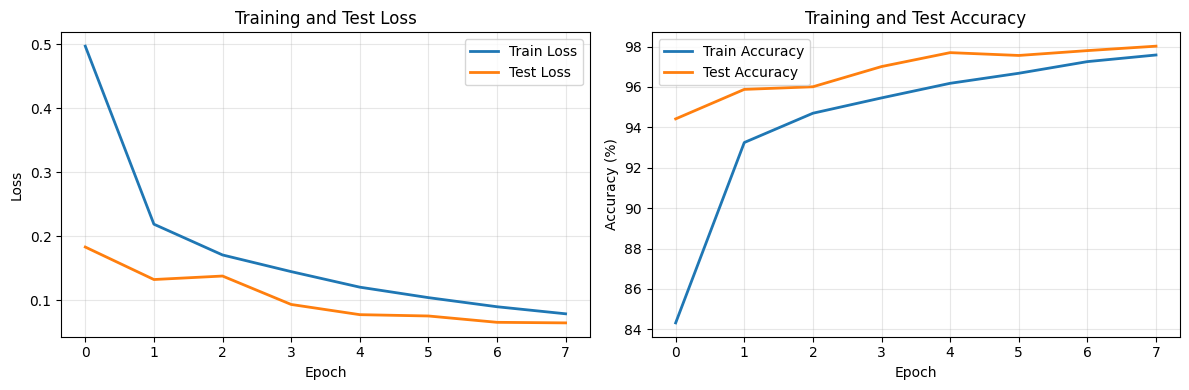


Final Test Accuracy: 98.02%
Best Test Accuracy: 98.02%


In [28]:
# Cell 10: Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(train_accs, label='Train Accuracy', linewidth=2)
axes[1].plot(test_accs, label='Test Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Test Accuracy: {test_accs[-1]:.2f}%")
print(f"Best Test Accuracy: {max(test_accs):.2f}%")

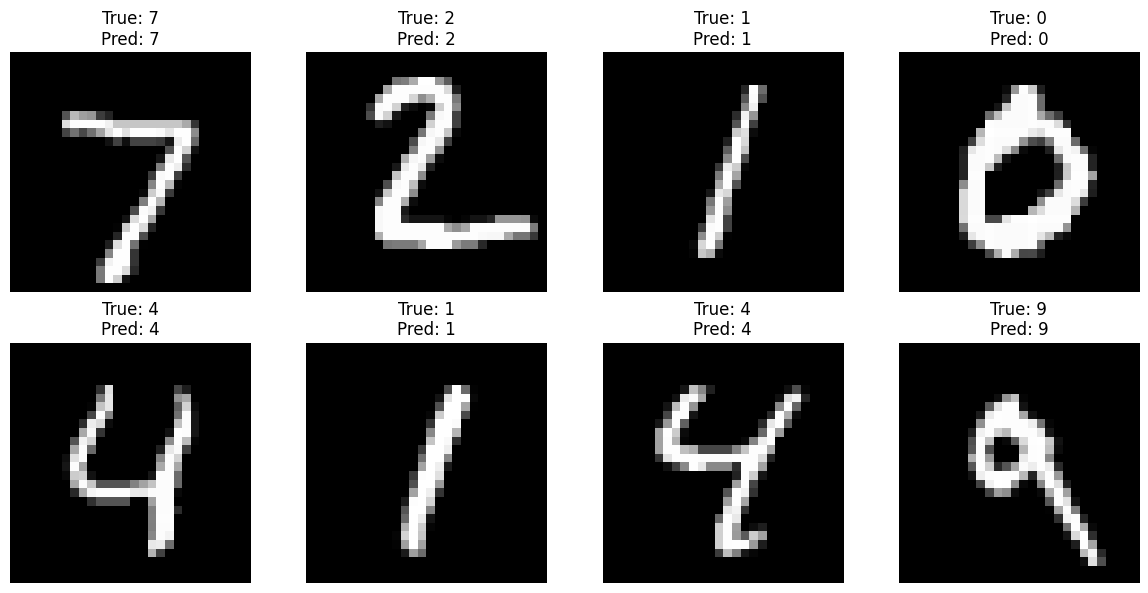

Batch accuracy: 8/8 = 100.0%


In [29]:
# Cell 11: Test on a few samples
# Test on a few samples
model.eval()
with torch.no_grad():
    # Get a batch from test set
    test_images, test_labels = next(iter(test_loader))
    test_images, test_labels = test_images.to(device), test_labels.to(device)
    
    # Predict
    outputs = model(test_images[:8])
    _, predictions = torch.max(outputs, 1)
    
    # Display
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()
    
    for i in range(8):
        img = test_images[i].cpu().squeeze() * 0.3081 + 0.1307  # Denormalize
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"True: {test_labels[i].item()}\nPred: {predictions[i].item()}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate accuracy on this batch
    correct = (predictions == test_labels[:8]).sum().item()
    print(f"Batch accuracy: {correct}/8 = {100*correct/8:.1f}%")

All-in-all this is an amazing result. Especially looking at the fact, that it wasn't even that difficult to implement due to the guided approach in the tutorial. 

## Congratz, you made it! :)